# Portfolio Explorer

Interactive tool to explore portfolios built via clustering + max-Sharpe optimization.

**Workflow:** Run all cells once, then play with the levers in the **Controls** section and click **Optimize**.

In [ ]:
# =====================================================================
# Google Colab setup — safely no-ops when running locally
# Recipients do NOT need a Drive shortcut. The notebook downloads the
# supporting files directly from a public Drive folder.
# =====================================================================
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules

# Public Google Drive folder ID containing the .py files and data/returns.parquet
# Get this from the folder's URL: drive.google.com/drive/folders/<THIS_PART>
DRIVE_FOLDER_ID = 'PASTE_YOUR_FOLDER_ID_HERE'

if IN_COLAB:
    # 1. Install dependencies
    subprocess.run(['pip', 'install', '-q',
                    'yfinance', 'PyPortfolioOpt', 'seaborn',
                    'ipywidgets', 'lxml', 'python-dateutil', 'gdown'], check=True)

    # 2. Enable widgets
    from google.colab import output
    output.enable_custom_widget_manager()

    # 3. Download project files from the public Drive folder
    os.makedirs('/content/Portfolio', exist_ok=True)
    os.chdir('/content/Portfolio')
    if not os.path.isfile('explorer_lib.py'):
        print('Downloading project files from Google Drive...')
        subprocess.run(['gdown', '--folder',
                        f'https://drive.google.com/drive/folders/{DRIVE_FOLDER_ID}',
                        '-O', '/content/Portfolio', '--remaining-ok'], check=True)
        # gdown places contents inside a subfolder named after the Drive folder
        # flatten if needed
        for name in os.listdir('.'):
            if os.path.isdir(name) and os.path.isfile(os.path.join(name, 'explorer_lib.py')):
                for f in os.listdir(name):
                    os.rename(os.path.join(name, f), f)
                os.rmdir(name)
                break

    sys.path.insert(0, '/content/Portfolio')
    print(f'Colab ready. Working directory: {os.getcwd()}')
    print('Files present:', sorted(os.listdir('.')))
else:
    print('Local Jupyter detected — no Colab setup needed.')

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML, Markdown
from scipy.cluster.hierarchy import dendrogram

from fetch_data import load_returns
from explorer_lib import (
    UNIVERSE_SOURCES, REGION_GROUP, ticker_region,
    optimize_portfolio, asset_metrics, equity_curve,
    backtest_strategy,
)

sns.set_theme(style='whitegrid')
RETURNS = load_returns()
print(f'Universe: {RETURNS.shape[1]} assets x {RETURNS.shape[0]} months')

Loading cached returns from data/returns.parquet...
Universe: 1904 assets x 60 months


## Universe — where the stocks come from

Source,Description
S&P 500,503 US large-cap stocks
Russell 1000,1003 US large+mid-cap stocks
NASDAQ 100,101 US tech-heavy large-caps
FTSE 100,100 UK large-caps
FTSE 250,250 UK mid-caps
DAX 40,40 German blue chips
CAC 40,40 French blue chips
SMI,20 Swiss large-caps
AEX,25 Dutch large-caps
OMXS 30,30 Swedish large-caps


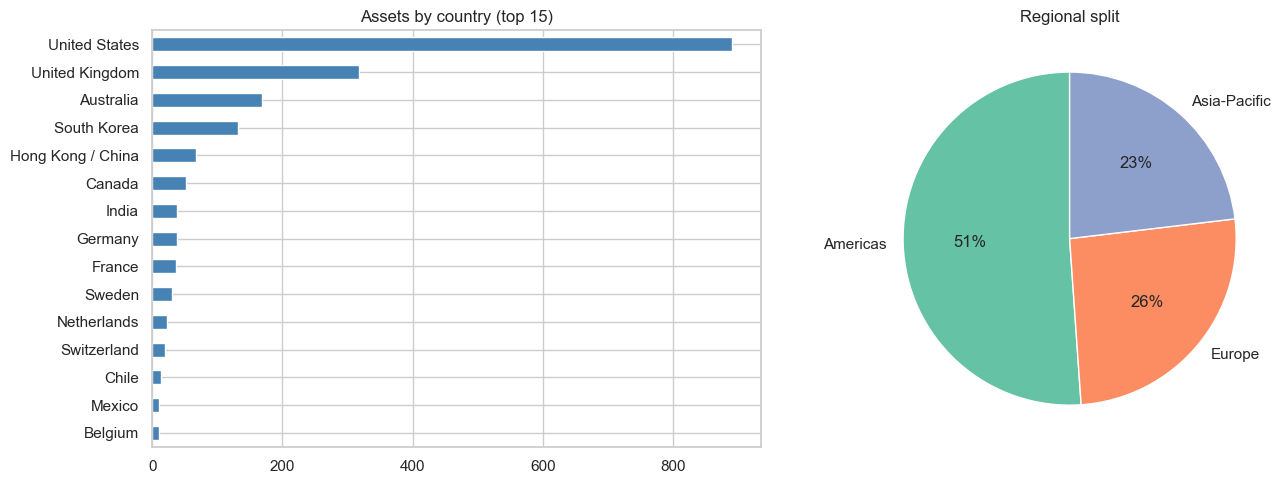

In [2]:
rows = ''.join(f'<tr><td><b>{n}</b></td><td>{d}</td></tr>' for n, d in UNIVERSE_SOURCES)
display(HTML(f'<table style="border-collapse:collapse"><tr><th>Source</th><th>Description</th></tr>{rows}</table>'))

regions = pd.Series([ticker_region(t) for t in RETURNS.columns]).value_counts()
groups = regions.groupby(lambda r: REGION_GROUP.get(r, 'Other')).sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
regions.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Assets by country (top 15)')
axes[0].invert_yaxis()
axes[1].pie(groups, labels=groups.index, autopct='%1.0f%%', startangle=90,
            colors=sns.color_palette('Set2'))
axes[1].set_title('Regional split')
plt.tight_layout(); plt.show()

## Controls

In [3]:
all_regions = sorted({ticker_region(t) for t in RETURNS.columns})

n_clusters = widgets.IntSlider(value=20, min=5, max=100, step=1, description='# clusters:',
                               style={'description_width': '140px'}, layout=widgets.Layout(width='420px'))
min_w = widgets.FloatSlider(value=0.0, min=0.0, max=0.10, step=0.005, description='Min weight:',
                            readout_format='.1%', style={'description_width': '140px'},
                            layout=widgets.Layout(width='420px'))
max_w = widgets.FloatSlider(value=0.25, min=0.05, max=1.0, step=0.05, description='Max weight:',
                            readout_format='.0%', style={'description_width': '140px'},
                            layout=widgets.Layout(width='420px'))
min_sharpe = widgets.FloatSlider(value=0.0, min=-1.0, max=2.5, step=0.1,
                                 description='Min individual Sharpe:',
                                 style={'description_width': '180px'},
                                 layout=widgets.Layout(width='460px'))
pinned = widgets.Text(value='', description='Pinned tickers:',
                     placeholder='e.g. AAPL, BRK-B, ASML.AS',
                     style={'description_width': '140px'},
                     layout=widgets.Layout(width='560px'))
excluded = widgets.Text(value='', description='Excluded tickers:',
                       placeholder='e.g. TSLA, GME',
                       style={'description_width': '140px'},
                       layout=widgets.Layout(width='560px'))
regions_w = widgets.SelectMultiple(options=all_regions, value=tuple(all_regions),
                                   description='Regions:', rows=8,
                                   style={'description_width': '140px'},
                                   layout=widgets.Layout(width='560px'))
run_bt = widgets.Checkbox(value=True, description='Run out-of-sample backtest')
optimize_btn = widgets.Button(description='Optimize', button_style='primary',
                              layout=widgets.Layout(width='180px', height='38px'))
out = widgets.Output()

controls = widgets.VBox([
    widgets.HBox([n_clusters, min_w, max_w]),
    min_sharpe,
    pinned, excluded, regions_w, run_bt, optimize_btn,
])
display(controls, out)

def _parse_tickers(text):
    return [t.strip().upper() for t in text.split(',') if t.strip()]

def render_portfolio(result, backtest_returns=None):
    weights = result['weights']
    weights = weights[weights > 0.001].sort_values(ascending=False)
    perf = result['performance']

    display(Markdown(f"### Portfolio summary  \n"
                     f"**Annual return:** {perf['annual_return']:.2%} &nbsp; "
                     f"**Volatility:** {perf['annual_vol']:.2%} &nbsp; "
                     f"**Sharpe (in-sample):** {perf['sharpe']:.2f} &nbsp; "
                     f"**Holdings:** {len(weights)}"))
    display(Markdown(
        "> **How to read these numbers**  \n"
        "> - **Annual return** — arithmetic-mean expected yearly return based on history.  \n"
        "> - **Volatility** — annualized standard deviation of returns. Lower = smoother ride.  \n"
        "> - **Sharpe (in-sample)** — excess return per unit of risk. *In-sample* means computed on the same data the optimizer used to pick weights, so it is the **best-case** scenario and tends to overstate what would happen going forward. The honest number is **Realized Sharpe** in the Out-of-Sample backtest section below.  \n"
        "> - **Holdings** — number of assets with non-trivial weight (>0.1%)."))

    display(Markdown("### Per-asset metrics\n"
                     "> One row per holding. *Weight* = capital allocated. *Annual return / Volatility / Sharpe* are computed on each asset individually. *Region* is inferred from the ticker suffix (no suffix = United States)."))
    metrics = asset_metrics(result['selected_returns'], weights)
    metrics_view = metrics.copy()
    metrics_view['weight'] = metrics_view['weight'].map('{:.2%}'.format)
    metrics_view['annual_return'] = metrics_view['annual_return'].map('{:.2%}'.format)
    metrics_view['volatility'] = metrics_view['volatility'].map('{:.2%}'.format)
    metrics_view['sharpe'] = metrics_view['sharpe'].map('{:.2f}'.format)
    display(metrics_view)

    # 1. Composition + region
    display(Markdown("### Composition\n"
                     "> **Left (pie):** how the portfolio is split across the chosen assets. Bigger slice = larger position.  \n"
                     "> **Right (bars):** the same weights aggregated by region — shows your geographic exposure at a glance."))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].pie(weights.values, labels=weights.index, autopct='%1.0f%%', startangle=90,
                colors=sns.color_palette('tab20', len(weights)))
    axes[0].set_title('Portfolio composition')
    by_region = metrics.groupby('region')['weight'].sum().sort_values(ascending=False)
    axes[1].barh(by_region.index, by_region.values, color='steelblue')
    axes[1].set_title('Weight by region'); axes[1].invert_yaxis()
    axes[1].set_xlabel('Weight'); axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    plt.tight_layout(); plt.show()

    # 2. Risk-return scatter
    display(Markdown("### Risk–return scatter\n"
                     "> Each dot is one asset in the portfolio. **X = volatility, Y = annualized return** — top-left is the ideal corner (high return for low risk). **Bubble size = portfolio weight** (bigger dot = more capital here). **Color = individual Sharpe** (green = good risk-adjusted return, red = poor). The optimizer tends to overweight green dots near the top-left, but is constrained by your max-weight lever."))
    fig, ax = plt.subplots(figsize=(10, 6))
    sizes = (metrics['weight'] * 2000).clip(lower=20)
    sc = ax.scatter(metrics['volatility'], metrics['annual_return'],
                    s=sizes, alpha=0.6, c=metrics['sharpe'], cmap='RdYlGn')
    for t in metrics.index:
        ax.annotate(t, (metrics.loc[t,'volatility'], metrics.loc[t,'annual_return']), fontsize=8)
    plt.colorbar(sc, label='Individual Sharpe')
    ax.set_xlabel('Annualized volatility'); ax.set_ylabel('Annualized return')
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    ax.set_title('Risk–return (bubble size = weight)')
    plt.tight_layout(); plt.show()

    # 3. Correlation heatmap
    display(Markdown("### Correlation matrix\n"
                     "> Pairwise correlations between the selected assets. **Red = move together (≈+1), Blue = move opposite (≈-1), White = independent (≈0)**. A *good* diversified portfolio shows mostly pale colors — meaning the holdings don't all rise and fall together. Lots of red blocks means hidden concentration risk: when one falls, the others likely will too."))
    fig, ax = plt.subplots(figsize=(10, 8))
    corr = result['selected_returns'][weights.index].corr()
    sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax,
                cbar_kws={'label': 'Correlation'})
    ax.set_title('Correlation matrix of selected assets')
    plt.tight_layout(); plt.show()

    # 4. Dendrogram (on full filtered universe)
    display(Markdown("### Dendrogram (cluster tree)\n"
                     "> Each leaf at the bottom is one asset from the **full filtered universe** (often hundreds of stocks). The tree shows hierarchical clustering by return correlation: assets that move similarly merge into a branch at low height, dissimilar ones merge higher up. **The horizontal cut line determines how many clusters you get** — the colored sub-trees below the cut are the clusters, and the optimizer picks one representative from each. Increasing *# clusters* lowers the cut and creates more, finer-grained groups."))
    fig, ax = plt.subplots(figsize=(15, 5))
    dendrogram(result['linkage'], labels=list(result['filtered_returns'].columns),
               ax=ax, leaf_font_size=6, no_labels=result['filtered_returns'].shape[1] > 150,
               color_threshold=result['linkage'][-(n_clusters.value-1), 2])
    ax.set_title(f'Dendrogram (cut into {n_clusters.value} clusters)')
    plt.tight_layout(); plt.show()

    # 5. Equity curves
    display(Markdown("### Equity curves\n"
                     "> Cumulative growth of $1 invested at the start.  \n"
                     "> - **Solid line — in-sample:** these specific weights applied across all of history. *Optimistic* because the optimizer already saw this data when picking weights.  \n"
                     "> - **Dashed line — out-of-sample backtest:** the *strategy* (re-running the whole pipeline each quarter, weights changing over time) applied to data the optimizer didn't see at the moment of each decision. This is the honest line.  \n"
                     "> A y-axis value of **6.0 means 6× your money (+500%)**, not 6%."))
    in_sample_returns = (result['selected_returns'][weights.index] * weights).sum(axis=1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(equity_curve(in_sample_returns).index, equity_curve(in_sample_returns).values,
            label='In-sample (this portfolio over full history)', linewidth=2)
    if 'SPY' in RETURNS.columns:
        spy = RETURNS['SPY'].loc[in_sample_returns.index].dropna()
        ax.plot(equity_curve(spy).index, equity_curve(spy).values,
                label='SPY benchmark', linewidth=2, alpha=0.7)
    if backtest_returns is not None and len(backtest_returns):
        ax.plot(equity_curve(backtest_returns).index, equity_curve(backtest_returns).values,
                label='Out-of-sample backtest (strategy)', linewidth=2, linestyle='--')
    ax.set_title('Equity curves'); ax.set_ylabel('Cumulative return (1.0 = starting capital)'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    if backtest_returns is not None and len(backtest_returns):
        bt = backtest_returns
        ann_r = (1 + bt.mean()) ** 12 - 1
        ann_v = bt.std() * np.sqrt(12)
        sh = (ann_r - 0.04) / ann_v
        eq = equity_curve(bt); dd = eq / eq.cummax() - 1
        display(Markdown(f"### Out-of-sample backtest  \n"
                         f"**Annual return:** {ann_r:.2%} &nbsp; "
                         f"**Volatility:** {ann_v:.2%} &nbsp; "
                         f"**Realized Sharpe:** {sh:.2f} &nbsp; "
                         f"**Max drawdown:** {dd.min():.2%} &nbsp; "
                         f"**Total OOS return:** {eq.iloc[-1] - 1:.2%}"))
        display(Markdown(
            "> **How to read these numbers** — these come from a walk-forward simulation: at each quarter we re-run the whole strategy on data up to that point only, then track how those fresh weights performed over the next quarter. Stitched together across ~2 years.  \n"
            "> - **Realized Sharpe** — the honest risk-adjusted return. Compare it to the *in-sample* Sharpe above: real strategies usually drop a lot here. A realized Sharpe above ~1.0 is genuinely good; 2+ is excellent.  \n"
            "> - **Max drawdown** — worst peak-to-trough loss you would have experienced during the test period. A -20% drawdown means there was a moment your portfolio was 20% below its prior high.  \n"
            "> - **Total OOS return** — cumulative return over the entire out-of-sample window."))

def on_optimize_click(b):
    with out:
        clear_output(wait=True)
        print('Optimizing...')
        try:
            result = optimize_portfolio(
                RETURNS,
                n_clusters=n_clusters.value,
                min_weight=min_w.value,
                max_weight=max_w.value,
                pinned=_parse_tickers(pinned.value),
                excluded=_parse_tickers(excluded.value),
                min_sharpe=min_sharpe.value if min_sharpe.value > -0.99 else None,
                regions=list(regions_w.value) if len(regions_w.value) < len(all_regions) else None,
            )
            bt_returns = None
            if run_bt.value:
                print('Running walk-forward backtest...')
                bt_returns = backtest_strategy(
                    RETURNS,
                    n_clusters=n_clusters.value,
                    min_weight=min_w.value, max_weight=max_w.value,
                    pinned=_parse_tickers(pinned.value),
                    excluded=_parse_tickers(excluded.value),
                    min_sharpe=min_sharpe.value if min_sharpe.value > -0.99 else None,
                    regions=list(regions_w.value) if len(regions_w.value) < len(all_regions) else None,
                )
            clear_output(wait=True)
            render_portfolio(result, bt_returns)
        except Exception as e:
            print(f'Error: {e}')
            import traceback; traceback.print_exc()

optimize_btn.on_click(on_optimize_click)
# Auto-run once
on_optimize_click(None)

Output()